In [125]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import numpy as np
sys.path.insert(0,'../src/')
np.random.seed(42)
%matplotlib inline

In [126]:
from lsst.daf.butler import Butler

In [127]:
%load_ext autoreload
%autoreload 2
from importlib import reload
import PSFtools as psfTools 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [128]:
butler = Butler('embargo', collections=['LSSTCam/runs/nightlyValidation'])

In [129]:
day_obs = 20260406
visitID = 2026040600010

In [130]:
detIDarr, detNAMEarr, detXarr, detYarr = psfTools.getCCD11array()

In [131]:
# central CCD
detIDarr[10], detNAMEarr[10] 

(94, 'R22_S11')

In [132]:
condition = f"day_obs={day_obs} AND visit={visitID} AND (detector={detIDarr[0]}"
for iID in range(1, len(detIDarr)):
    condition += f" OR detector={detIDarr[iID]}"
condition += f")" 

In [133]:
# with the condition above, this selects all 21 central sensors from each raft
visitimage_refs = butler.query_datasets('preliminary_visit_image', 
                                        where=condition,
                                        order_by=['visit', 'detector'],
                                        with_dimension_records=True,
                                        limit=2000)
visits = []
for ref in visitimage_refs:
    visit = ref.dataId["visit"]
    visits.append(visit) 
len(visits)

21

detectorID = 4


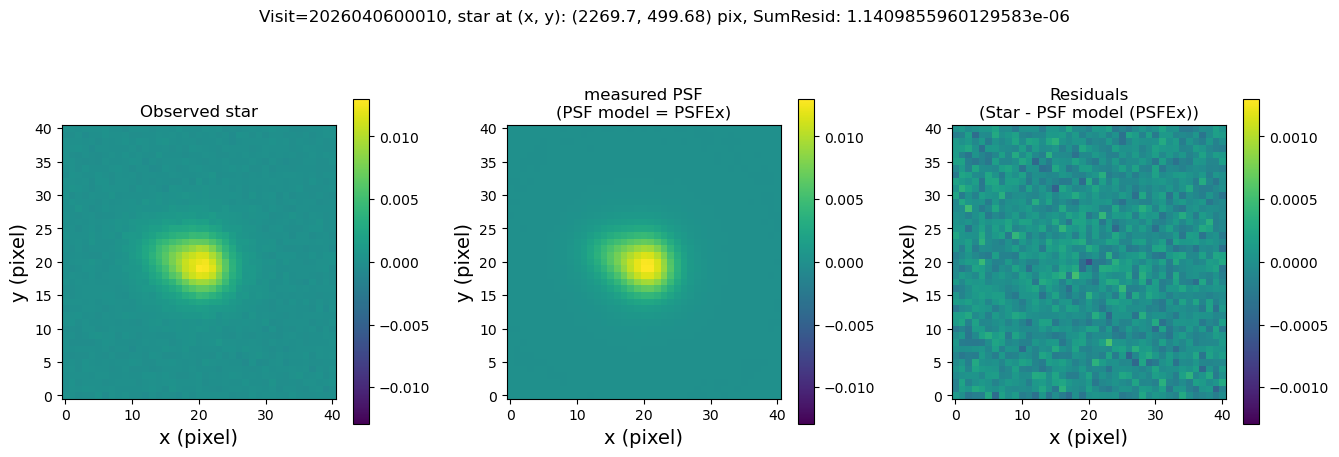

detectorID = 13


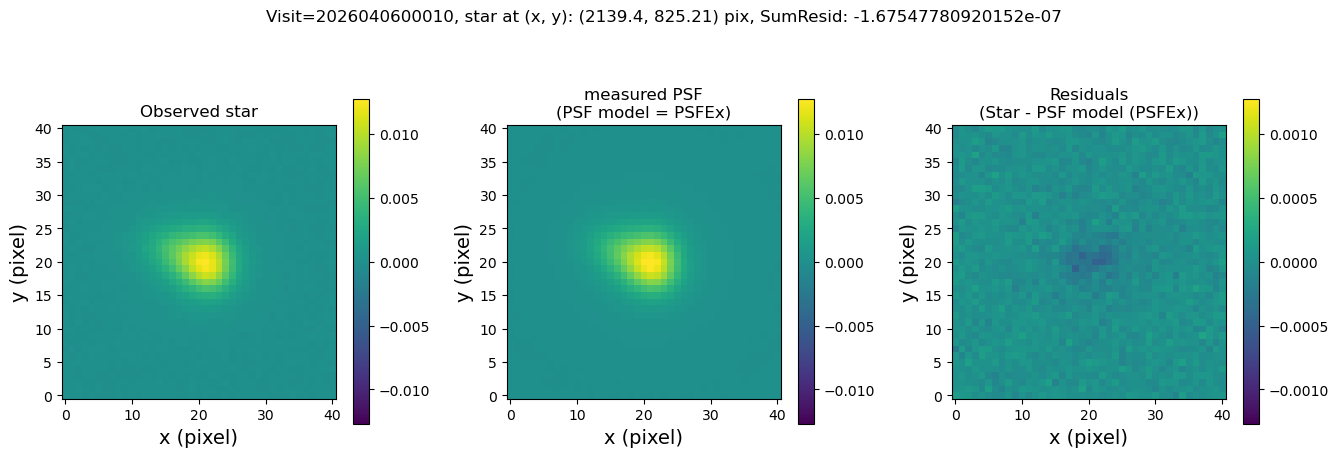

detectorID = 22


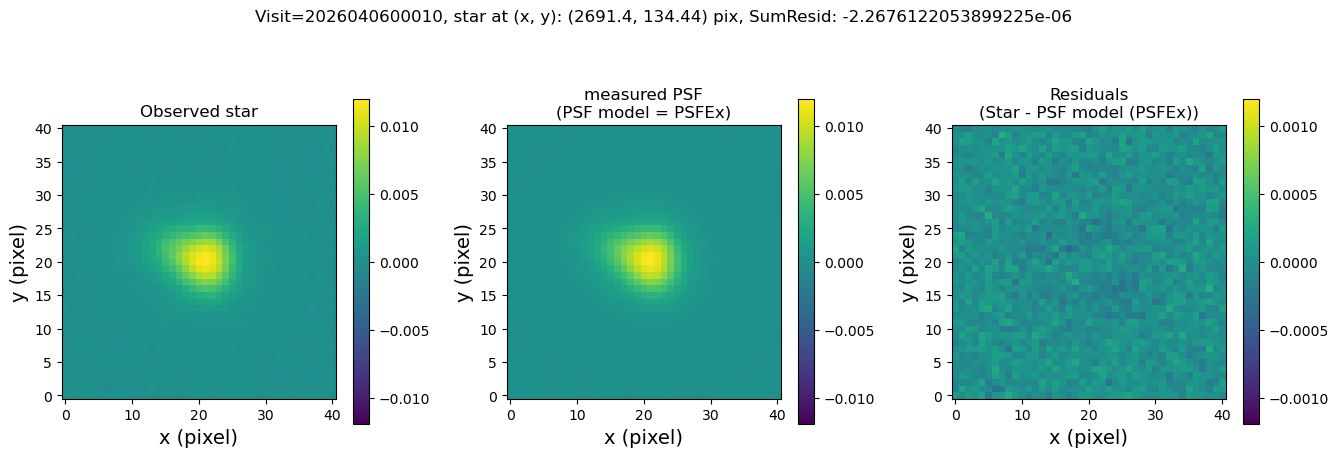

detectorID = 31


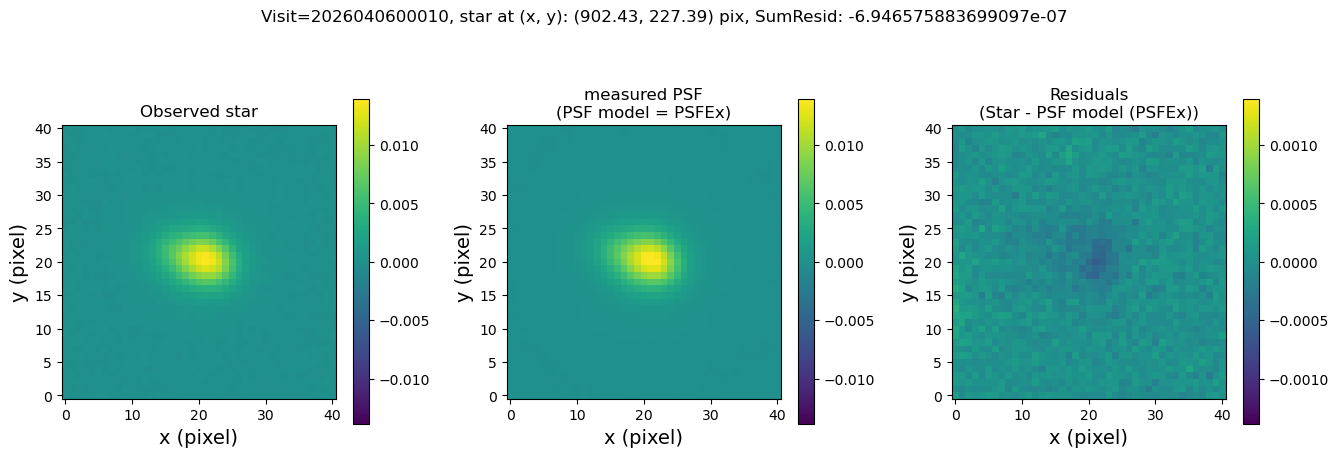

detectorID = 40


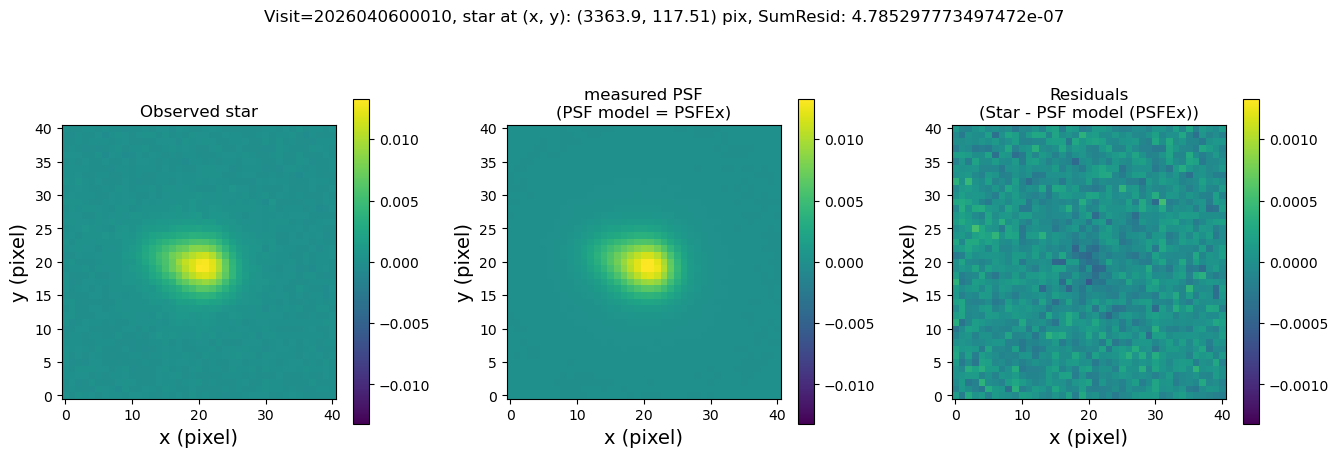

detectorID = 49


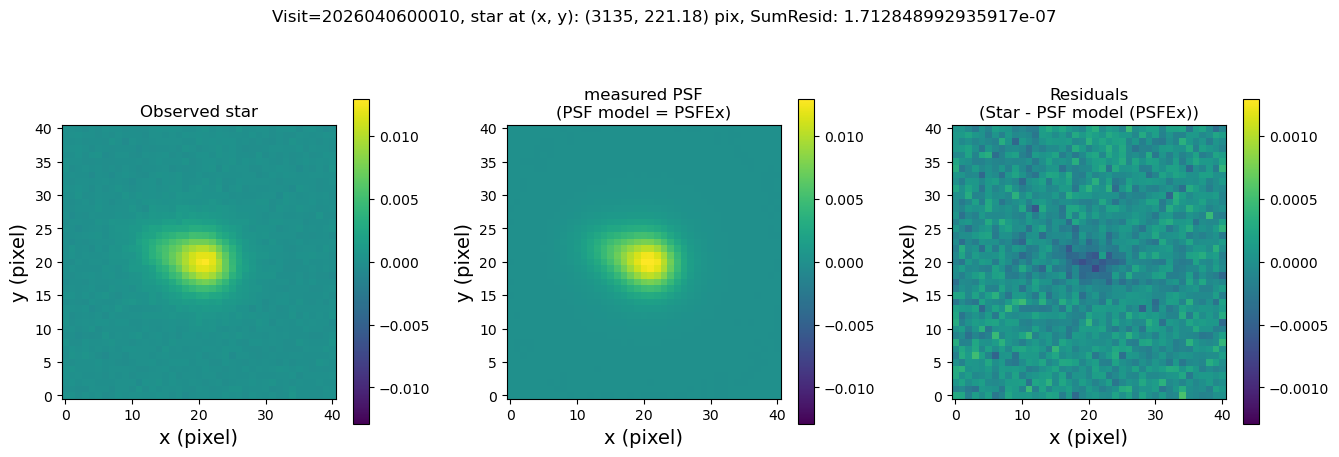

detectorID = 58


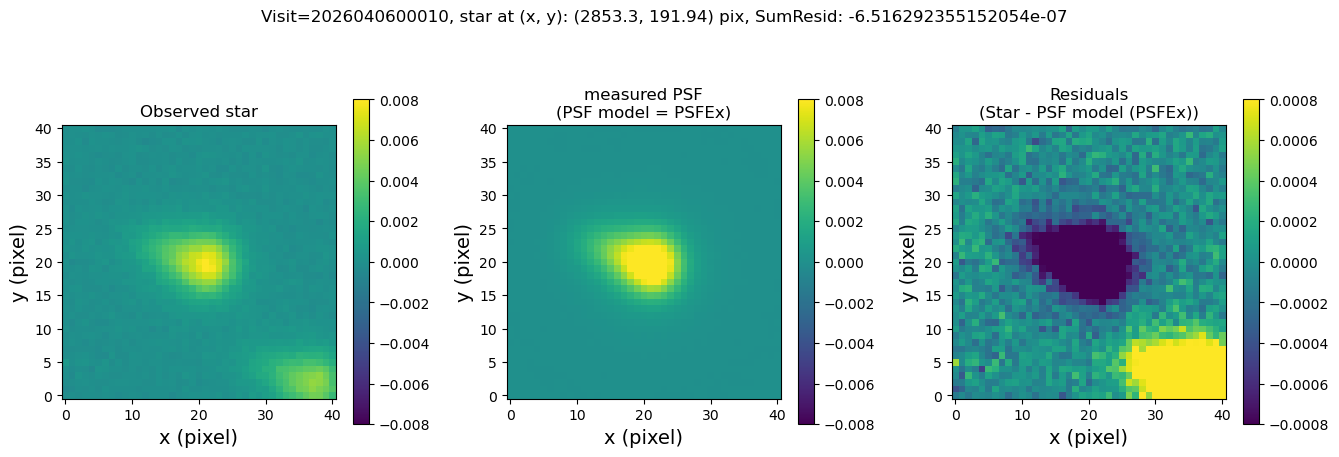

detectorID = 67


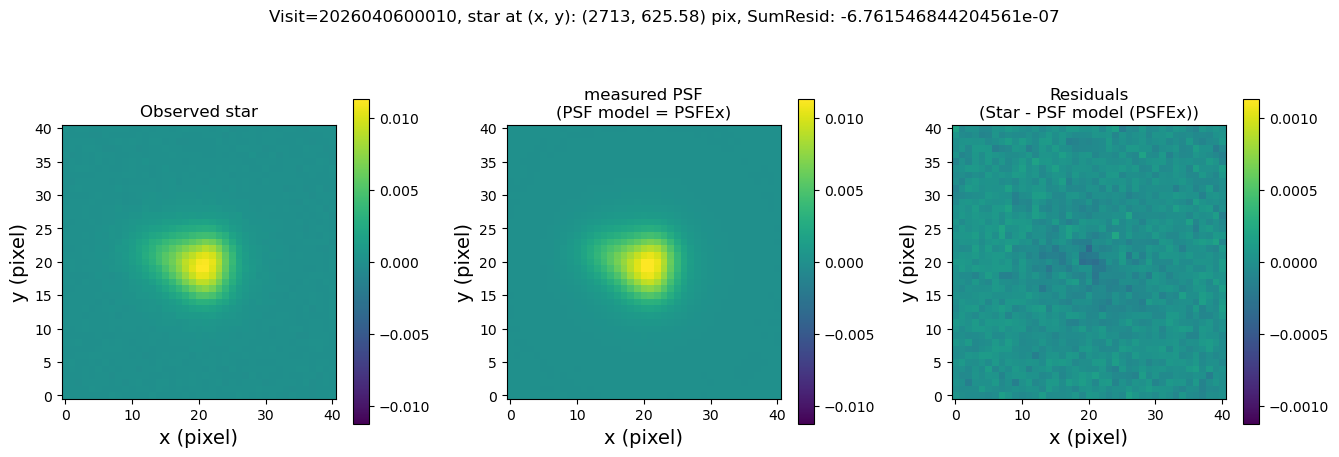

detectorID = 76


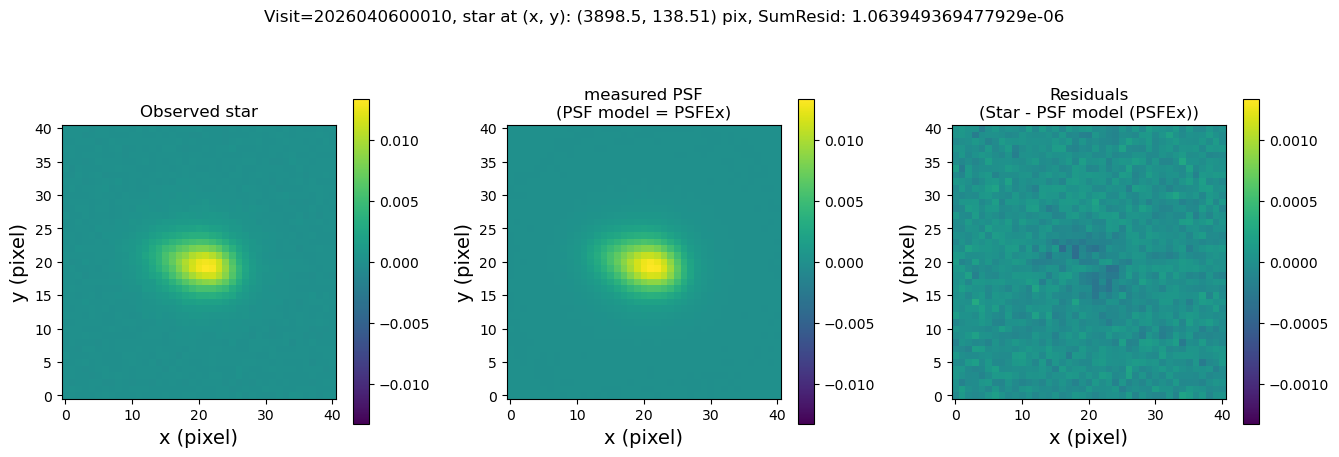

detectorID = 85


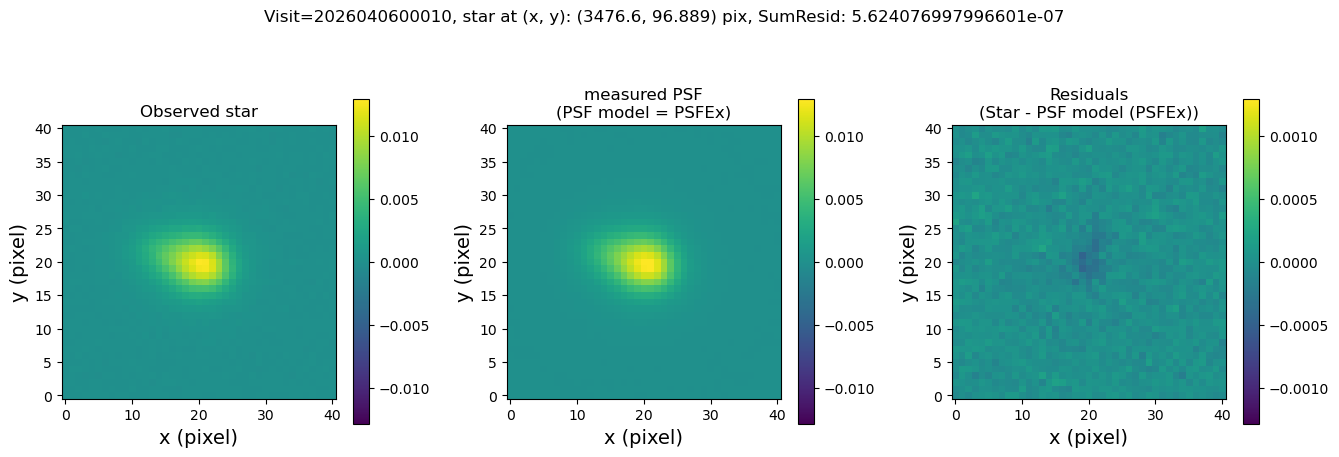

detectorID = 94


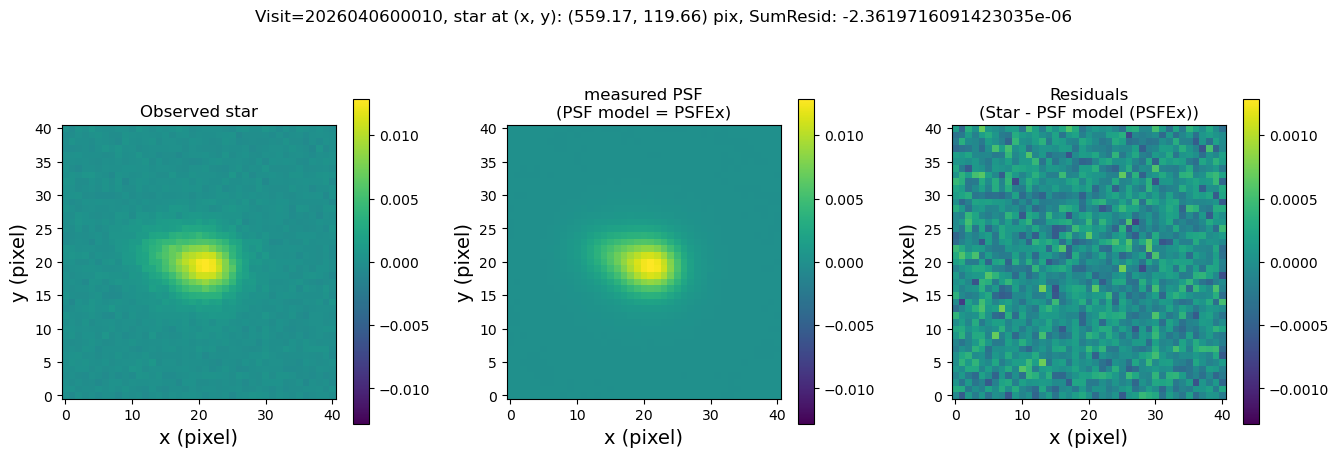

detectorID = 103


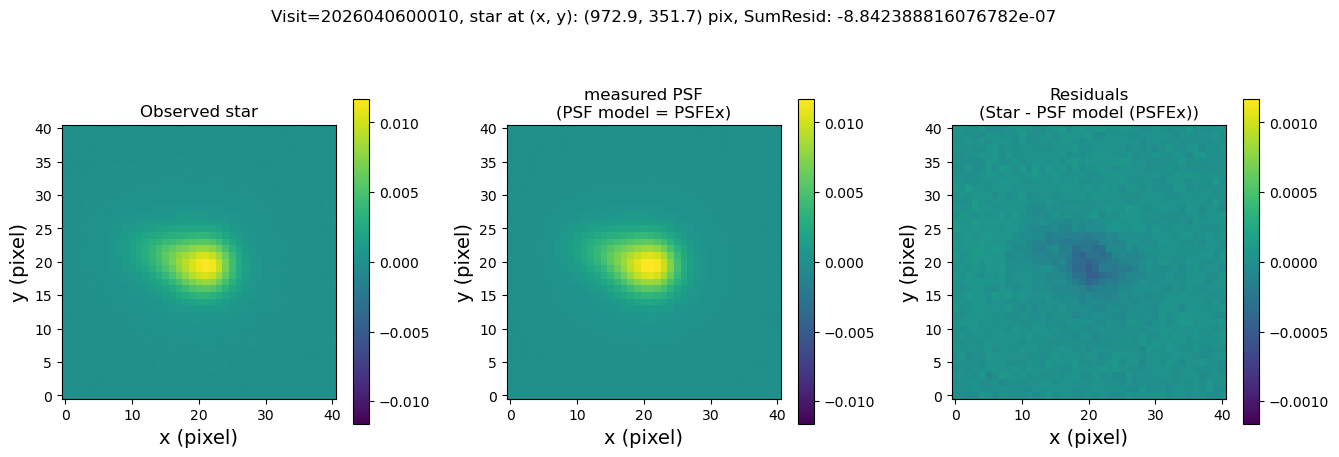

detectorID = 112


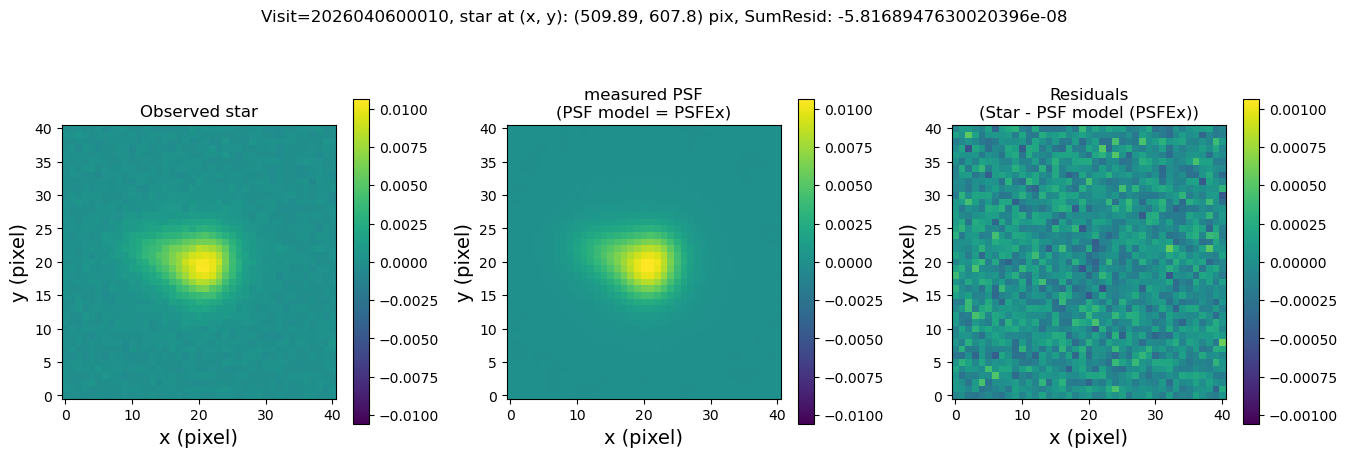

detectorID = 121


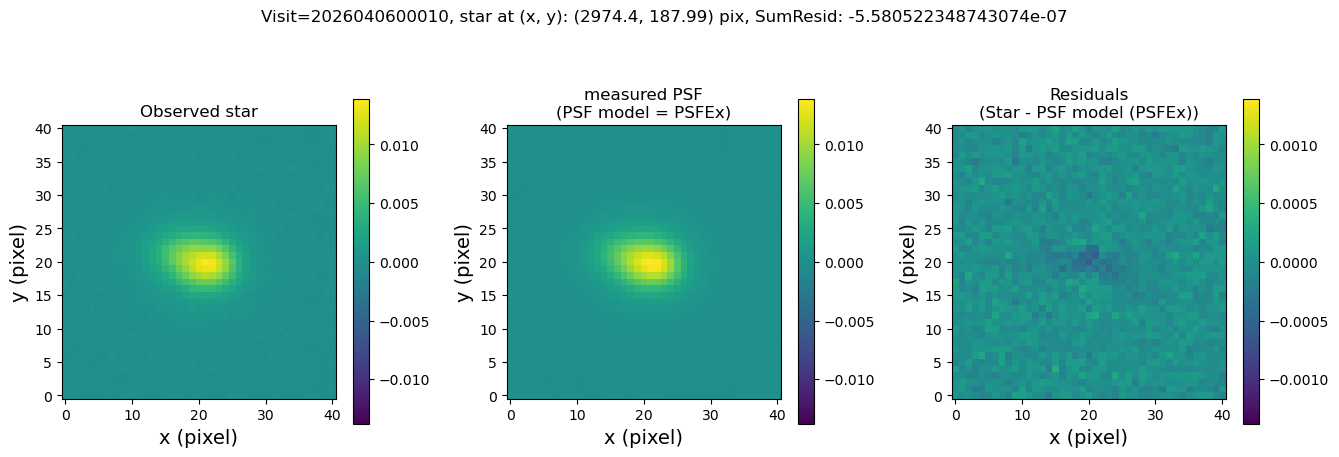

detectorID = 130


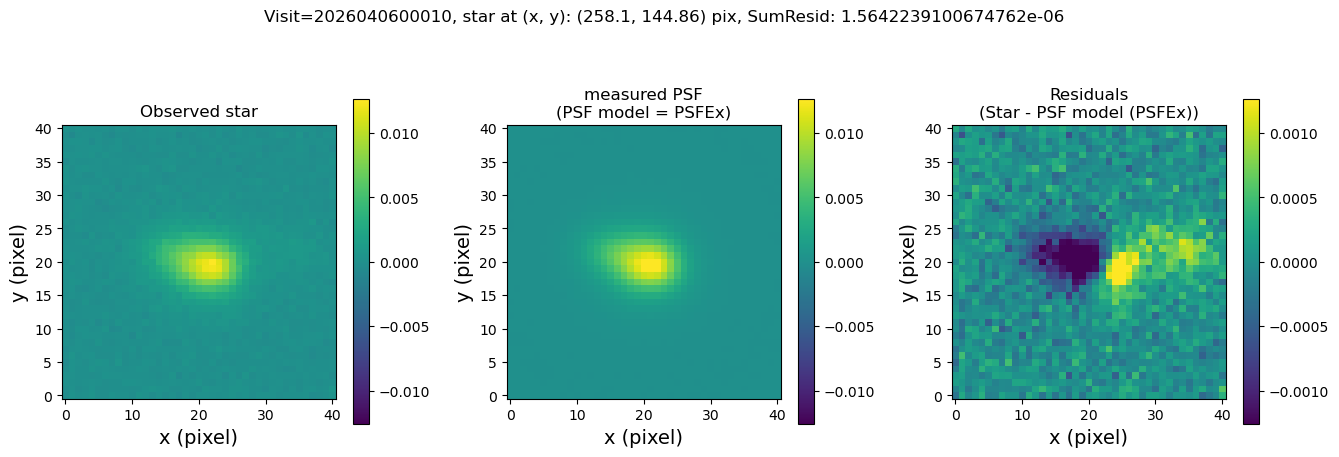

detectorID = 139


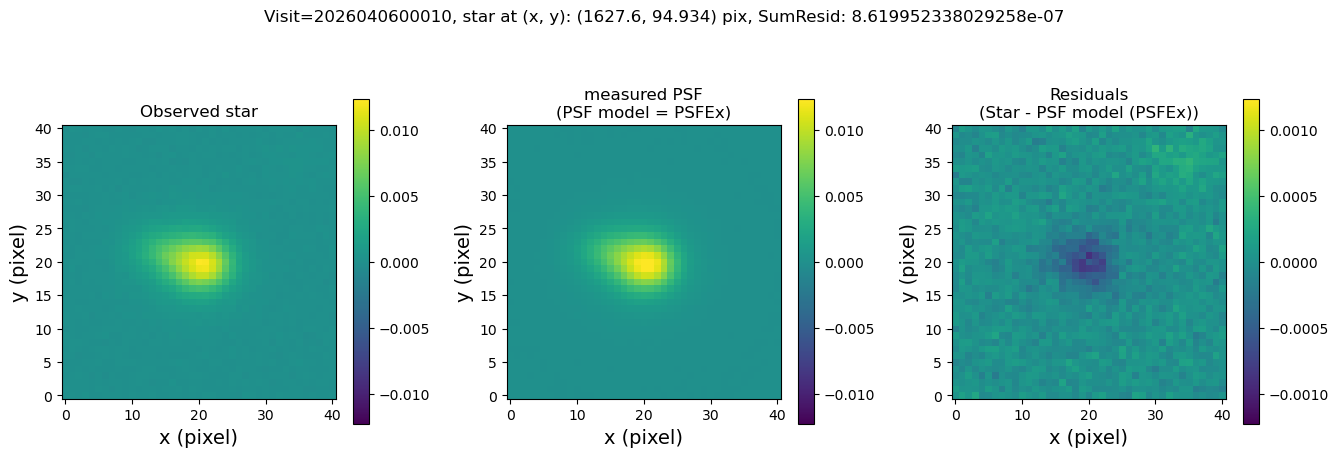

detectorID = 148


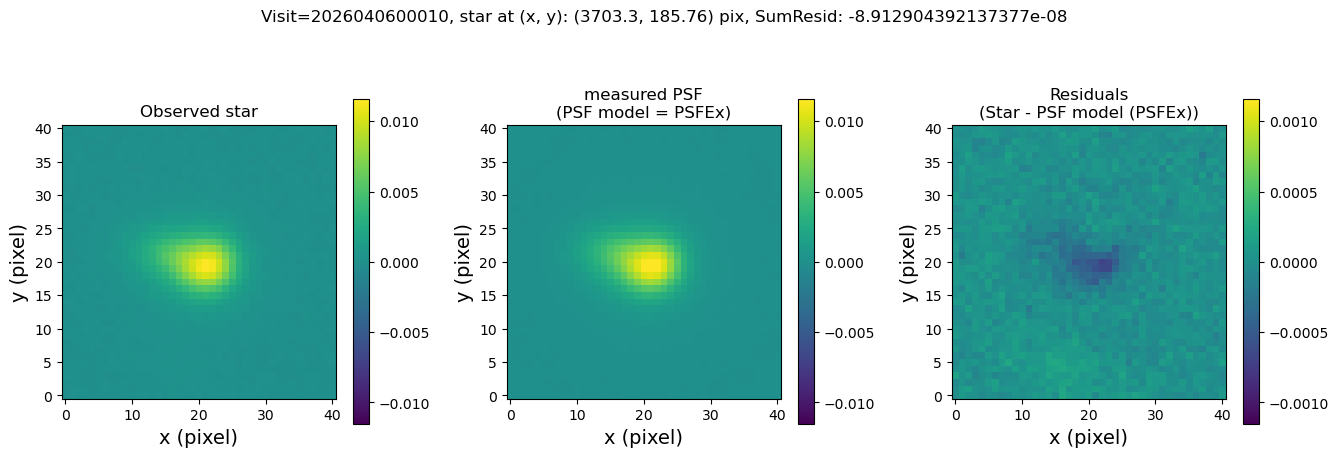

detectorID = 157


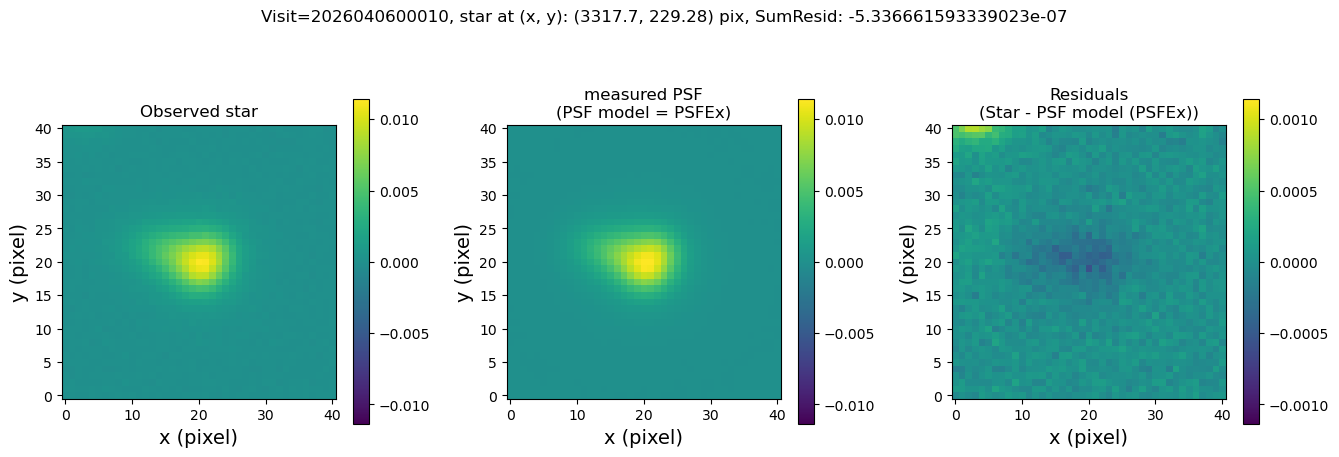

detectorID = 166


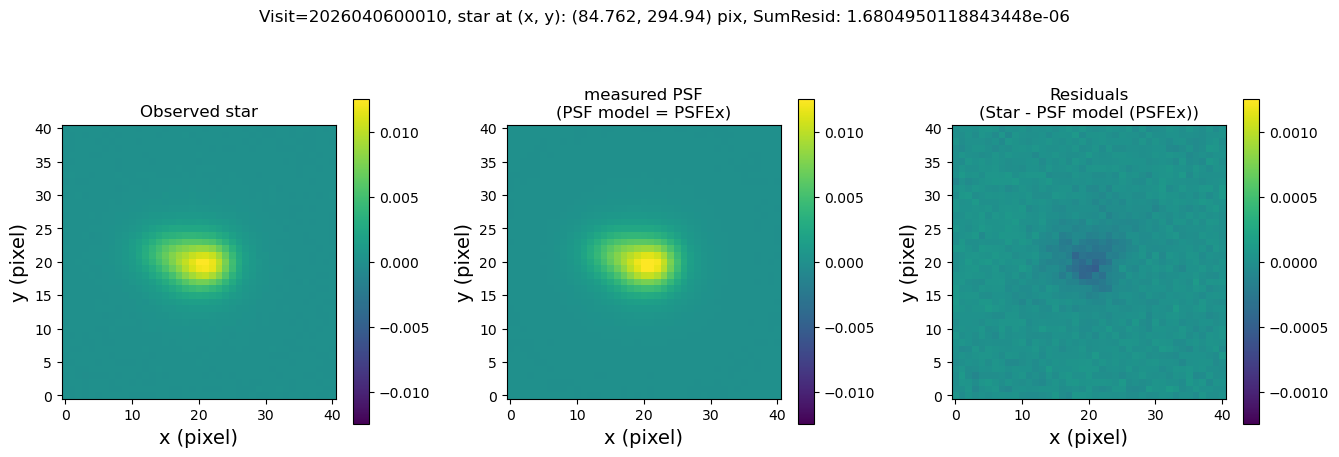

detectorID = 175


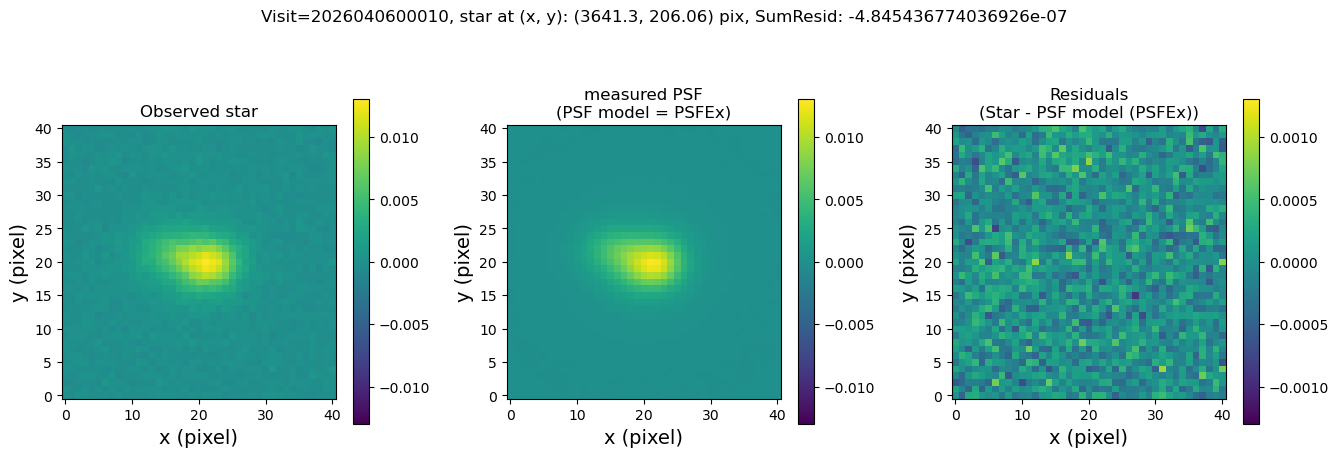

detectorID = 184


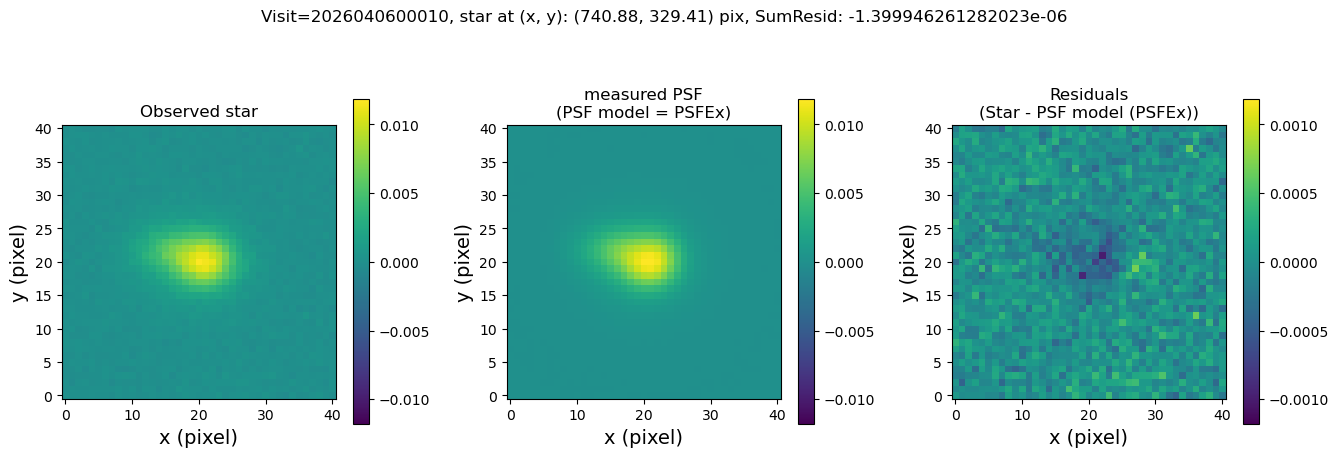

In [134]:
# 1 visit, 1 star per detector 
starIndexMin = 0
starIndexMax = 1
for iID in range(0, len(visitimage_refs)): 
    detectorID = detIDarr[iID]
    print('detectorID =', detectorID)
    psfTools.plotStarWithPSF(butler, visits, iID, visitimage_refs, detectorID, starIndexMin, starIndexMax)

detectorID = 4


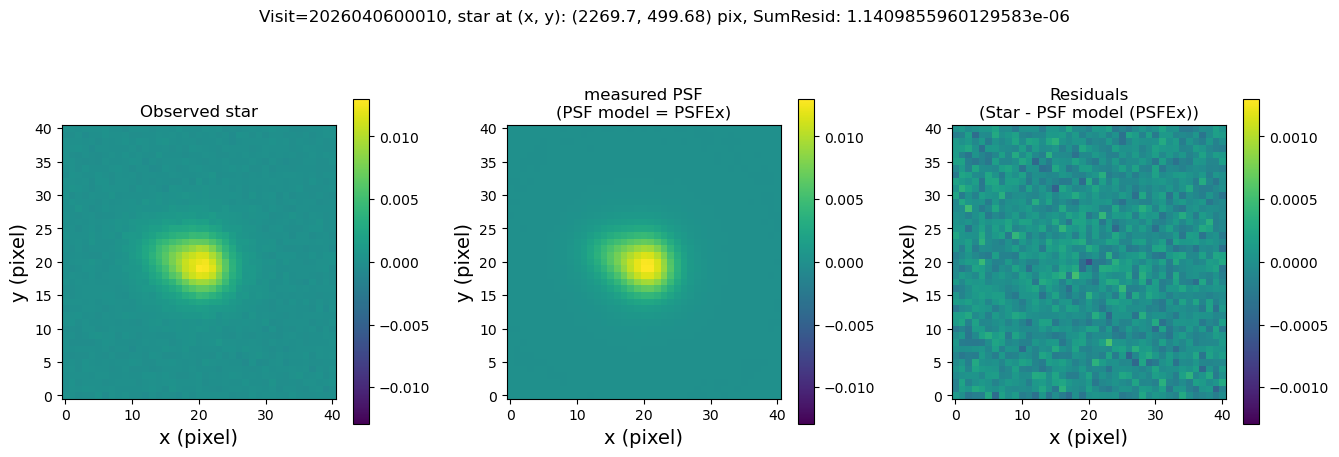

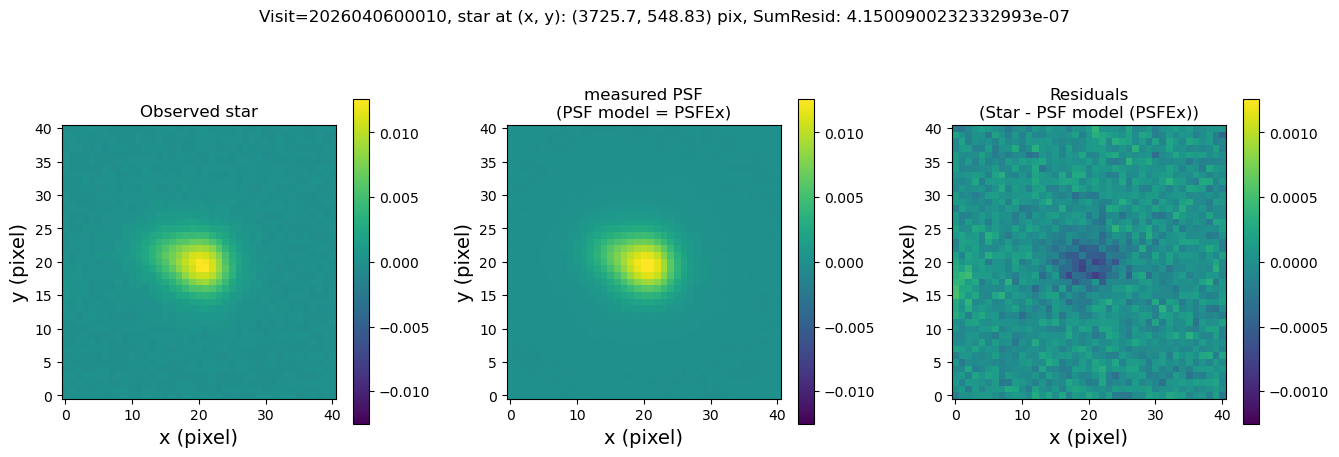

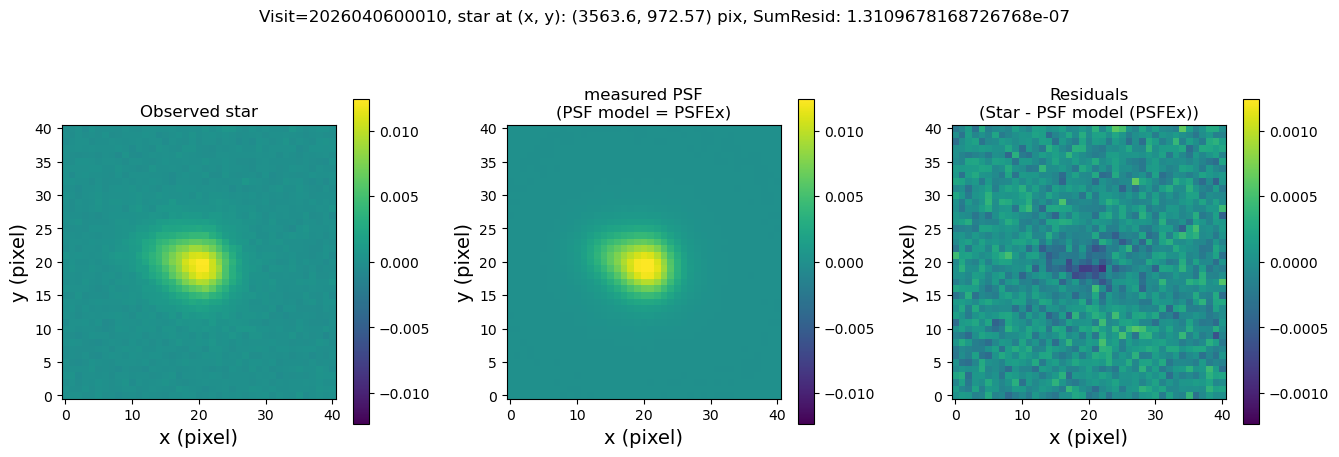

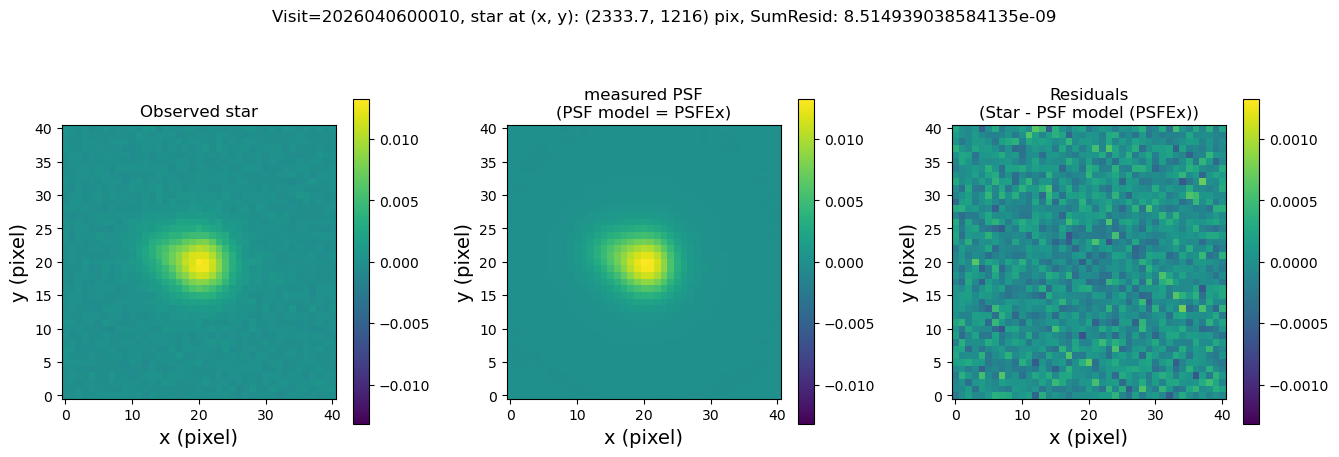

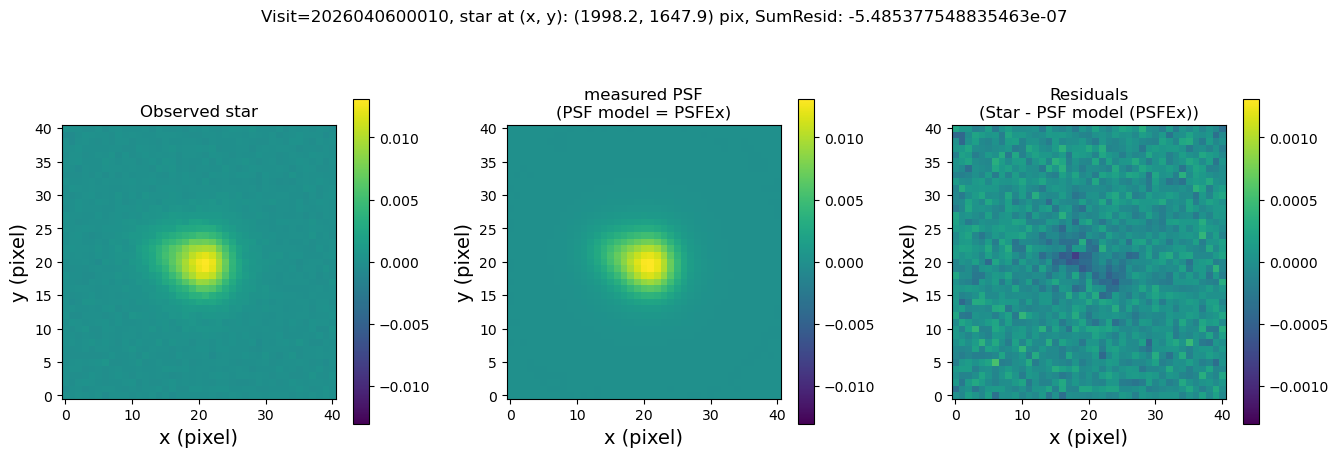

In [135]:
# 1 visit, 1 detector, 5 stars  
starIndexMin = 0
starIndexMax = 5
for iID in range(0, 1): 
    detectorID = detIDarr[0]
    print('detectorID =', detectorID)
    psfTools.plotStarWithPSF(butler, visits, 0, visitimage_refs, detectorID, starIndexMin, starIndexMax)

### now show only stars, without models, in focal plane geometry 

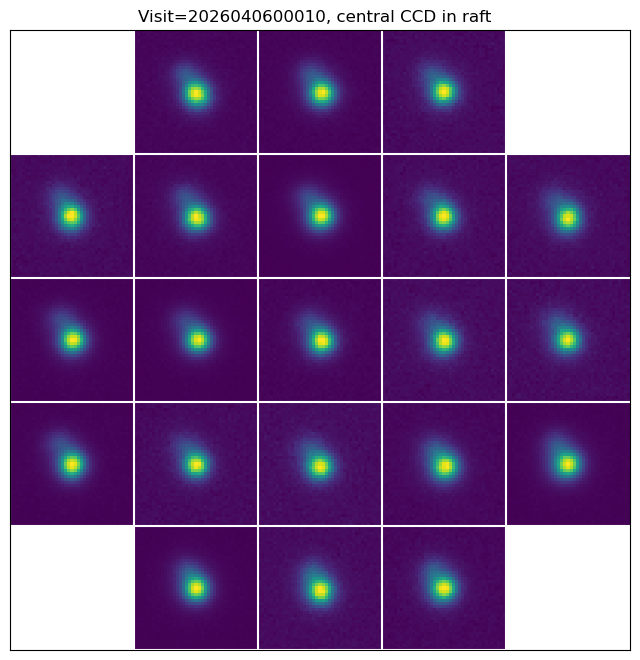

In [136]:
psfTools.plotRaftCentralCCD(visits[0], detXarr, detYarr, starsAll)

#### try different night and visit

In [164]:
day_obs = 20260407
visitID = 2026040700113

day_obs = 20260406
visitID = 2026040600118

In [165]:
# detector IDs, names and locations 
detIDarr, detNAMEarr, detXarr, detYarr = psfTools.getCCD11array()

# condition for selection of all central CCDs 
condition = f"day_obs={day_obs} AND visit={visitID} AND (detector={detIDarr[0]}"
for iID in range(1, len(detIDarr)):
    condition += f" OR detector={detIDarr[iID]}"
condition += f")" 

# with the condition above, this selects all 21 central sensors from each raft
visitimage_refs = butler.query_datasets('preliminary_visit_image', 
                                        where=condition,
                                        order_by=['visit', 'detector'],
                                        with_dimension_records=True,
                                        limit=2000)
visits = []
for ref in visitimage_refs:
    visit = ref.dataId["visit"]
    visits.append(visit) 

In [166]:
starsAll = []
# 1 visit, 1 star per detector 
starIndexMin = 0
starIndexMax = 1
for iID in range(0, len(visitimage_refs)): 
    detectorID = detIDarr[iID]
    # print('detectorID =', detectorID)
    starsAll.append(psfTools.returnsStars(butler, visits, iID, visitimage_refs, detectorID, starIndexMin, starIndexMax))

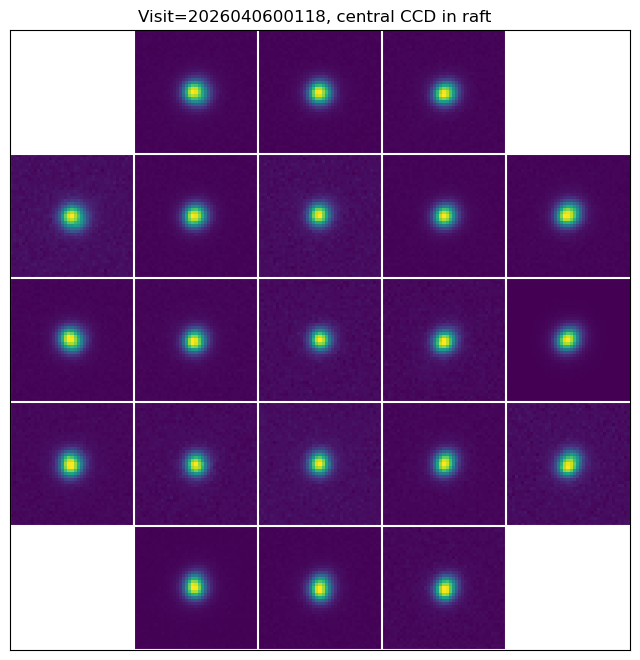

In [167]:
psfTools.plotRaftCentralCCD(visits[0], detXarr, detYarr, starsAll)

In [169]:
star = starsAll[10]
star2D = star[0]

In [181]:
validate_stamp(star2D)

{'valid': True,
 'message': 'stamp validation passed',
 'finite_fraction': 1.0,
 'shape': (41, 41)}

In [ ]:
import importlib
import fittingTools
importlib.reload(fittingTools)
importlib.reload(psfTools)

STARS_PER_DETECTOR = 5

all_star_records, all_visit_results = psfTools.run_detector_analysis(
    butler, visitimage_refs, detNAMEarr, stars_per_detector=STARS_PER_DETECTOR)

In [ ]:
# OPTIONAL: visualise model comparisons per detector.
# Requires the fitting cell above to have been run; independent of the master table cell.
import time

page_size = 3

for det_key, visit_data in all_visit_results.items():
    results     = visit_data['results']
    detector_id = visit_data['detector_id']
    band        = visit_data['band']

    t0 = time.time()
    fittingTools.plot_model_comparison_pages(results, page_size, visitID, detector_id, band)
    best_model_counts = fittingTools.plot_best_model_counts(results)
    t_plot = time.time() - t0
    print('Detector %s: plotting done for %d stars in %.2fs (%d per page)' % (
        detector_id, len(results), t_plot, page_size))
    print('Best model counts:', best_model_counts)

In [ ]:
# Build master table from all accumulated star records.
# Requires the fitting cell above to have been run; the plotting cell is optional.
master_table = fittingTools.build_master_table(all_star_records)

# Save to CSV. Set CSV_OUTPUT_PATH to the desired file location before running.
CSV_OUTPUT_PATH = 'single_visit_21rafts_psf_table.csv'
fittingTools.save_master_table(master_table, CSV_OUTPUT_PATH)